In [1]:
import os

In [2]:
%pwd

'C:\\Users\\Lenovo\\CHESS\\research'

In [5]:
os.chdir("../")

In [6]:
%pwd

'C:\\Users\\Lenovo\\CHESS'

In [14]:
data = os.path.join("artifacts" ,"Data" , "raw_games.pgn")

In [8]:
from chess import pgn

In [ ]:
import re

In [36]:
rating = []
with open ("artifacts/Data/raw_games.pgn" , "r" , encoding="utf-8") as pgn_file :

    for line in pgn_file :
        if line.startswith(("[WhiteElo" , "[BlackElo"))  :
            match = re.search(r'"(\d+)"', line)
            if match :
                rating.append(int(match.group(1)))



In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

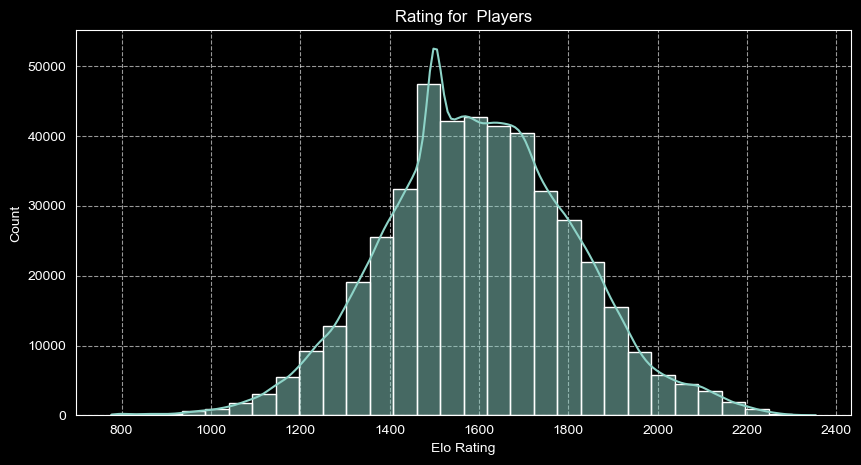

In [37]:
plt.figure(figsize=(10, 5))
sns.histplot(rating, bins=30, kde=True)
plt.title("Rating for  Players")
plt.xlabel("Elo Rating")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [38]:
from collections import Counter

In [47]:
openings = []
with open (data  , "r" , encoding="utf-8") as pgn_file :
    for line in pgn_file :
        if line.startswith("[Opening "):
            match = re.search(r'"(.*?)"', line)
            if match :
                openings.append(match.group(1))

    topOpenings = Counter(openings).most_common(10)
    names , counts = zip(*topOpenings)

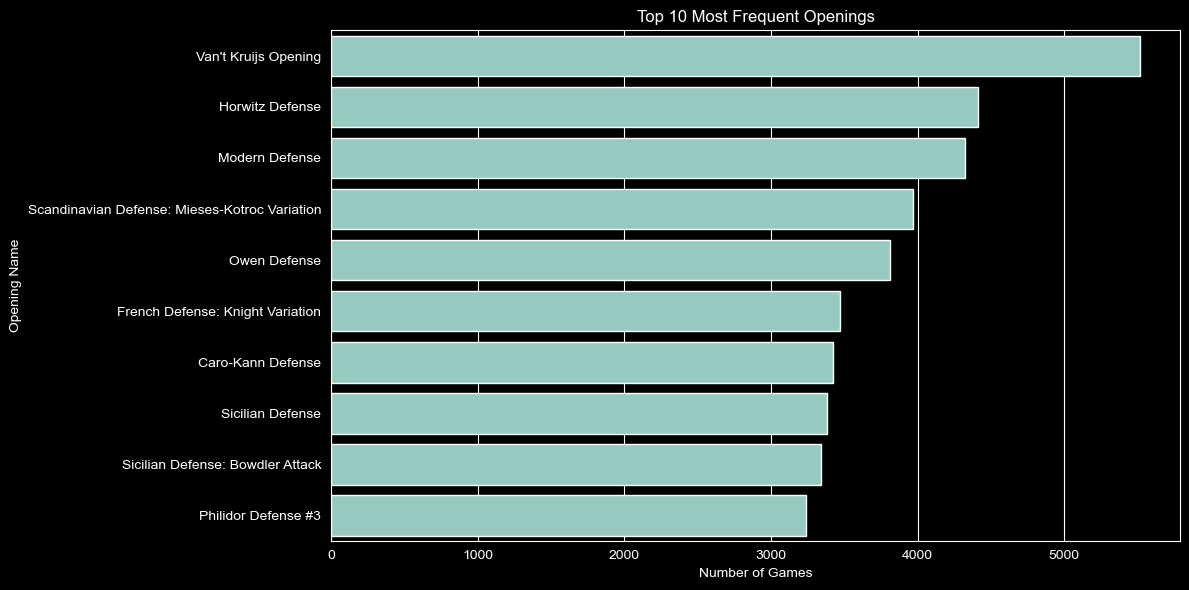

In [50]:
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(names))
plt.title("Top 10 Most Frequent Openings")
plt.xlabel("Number of Games")
plt.ylabel("Opening Name")
plt.tight_layout()
plt.show()

In [51]:
terminations = []
with open(data, "r", encoding="utf-8") as f:
    for line in f:
        if line.startswith("[Termination"):
            match = re.search(r'"(.*?)"', line)
            if match:
                terminations.append(match.group(1))

    counts = Counter(terminations)

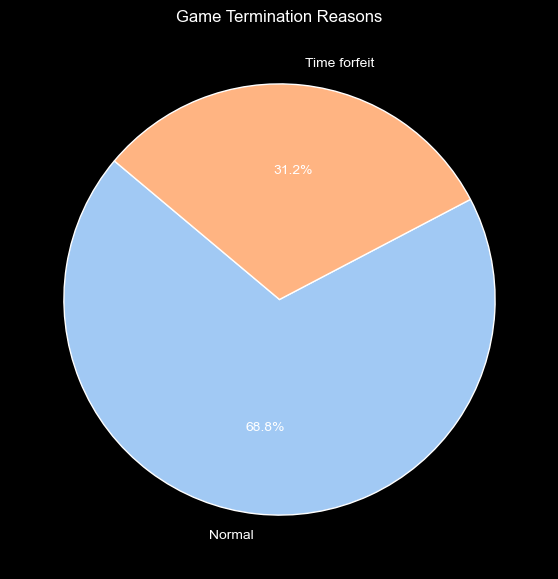

In [53]:
plt.figure(figsize=(7, 7))
plt.pie(
        counts.values(),
        labels=counts.keys(),
        autopct="%1.1f%%",
        startangle=140,
        colors=sns.color_palette("pastel"),
    )
plt.title("Game Termination Reasons")
plt.show()